## 데이터분석 과정
1. 문제정의 : 가치가있는 문제를 찾고 분석의 목적 설정, 분석대상에대한 전문 지식 쌓기
2. 데이터 수집: 분석에 필요한 데이터 확보
3. 데이터 전처리: 데이터셋 확인, 중복값 및 결측값 제거, 이상치 처리 등
4. 데이터 분석: 모델링이 완료된 데이터를 수학적 기법으로 통계분석, 인공지능 모델학습을 통한 예측
및 분류, 시각화
5. 해석 및 활용: 분석결과를 설득력있게 정리 및 전달

## 1. 탐구 주제명

최저임금 상승에 따른 물가 예측

## 2. 탐구 배경 및 필요성

물가 상승의 원인 중 하나가 인건비 상승 즉, 최저임금의 상승이다. 최저임금은 미리 공시하다는 점을 이용해 물가 상승을 예측하여 미리 기업이나 가계에서 소비를 계획할 수 있도록 하기 위해서 탐구하게 되었다.

## 3. 데이터 수집

① 물가 데이터 수집하기

참고자료 : https://kosis.kr/index/index.do

② 최저임금 데이터 수입하기

참고자료 : https://www.minimumwage.go.kr/main.do

## 4. 데이터 분석

#####한글처리

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   # 시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 # 해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 15 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

###1.데이터분석

⑤ 라이브러리 불러오기

In [2]:
# pandas, numpy 및 pyplot 라이브러리를 불러온다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 로컬 컴퓨터의 파일을 코랩으로 업로드한다.
from google.colab import files
files.upload()

Saving 소비자물가지수_최저임금.csv to 소비자물가지수_최저임금.csv


{'소비자물가지수_최저임금.csv': b'\xbd\xc3\xc1\xa1,\xb9\xb0\xb0\xa1\xc1\xf6\xbc\xf6,\xc3\xd6\xc0\xfa\xc0\xd3\xb1\xdd\r\n1989,35.441,600\r\n1990,38.48,690\r\n1991,42.071,820\r\n1992,44.685,925\r\n1993,46.831,1005\r\n1994,49.765,1085\r\n1995,51.995,1170\r\n1996,54.555,1275\r\n1997,56.977,1400\r\n1998,61.258,1485\r\n1999,61.756,1525\r\n2000,63.151,1600\r\n2001,65.719,1865\r\n2002,67.534,2100\r\n2003,69.908,2275\r\n2004,72.418,2510\r\n2005,74.413,2840\r\n2006,76.081,3100\r\n2007,78.01,3480\r\n2008,81.656,3770\r\n2009,83.906,4000\r\n2010,86.373,4110\r\n2011,89.85,4320\r\n2012,91.815,4580\r\n2013,93.01,4860\r\n2014,94.196,5210\r\n2015,94.861,5580\r\n2016,95.783,6030\r\n2017,97.645,6470\r\n2018,99.086,7530\r\n2019,99.466,8350\r\n2020,100,8590\r\n2021,102.5,8720\r\n2022,107.71,9160\r\n'}

In [3]:
# 업로드한 '물기지수_실업률.csv' 파일을 df_bike에 저장한다(한글 인코딩으로 설정).
df = pd.read_csv('소비자물가지수_최저임금.csv',encoding='cp949')

# df의 5개 데이터를 출력한다
df.head()

,시점,물가지수,최저임금
0,1989,35.441,600
1,1990,38.480,690
2,1991,42.071,820
3,1992,44.685,925
4,1993,46.831,1005


####2. 탐색적 데이터 분석

① 데이터 세트의 통계 정보 확인하기

데이터 속성의 통계 대푯값을 확인하고, 데이터 타입, 결측치 등을 확인해 보자.

In [4]:
# 저장된 데이터의 빈칸이 아닌 값과 자료형을 확인한다
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시점      34 non-null     int64  
 1   물가지수    34 non-null     float64
 2   최저임금    34 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 944.0 bytes


총 3개의 속성이 있으며 ‘시점'과 '최저임금'은 정수형, '물가지수'는 실수형 데이터로 불러 온 것을 확인할 수 있다.

In [5]:
# 데이터의 개수, 평균, 표준편차 등의 대푯값을 분석한다.
df.describe()

,시점,물가지수,최저임금
count,34.000000,34.000000,34.000000
mean,2005.500000,74.379559,3618.529412
std,9.958246,21.105135,2626.094153
min,1989.000000,35.441000,600.000000
25%,1997.250000,58.047250,1421.250000
50%,2005.500000,75.247000,2970.000000
75%,2013.750000,93.899500,5122.500000
max,2022.000000,107.710000,9160.000000


총  34건의 데이터가 있으며 describe( ) 함수에서 수치형 데이터의 통계치가 표시되므로 ‘시점', '물가지수', '최저임금'에 대한 통계치를 확인할 수 있다. 이때 ‘시점’은 1989년에서 2022년까지 분포하고 있으며 ‘물가지수’는 35.441에서 107.71까지. ‘최저임금’은 600~ 9160으로 차이가 상당히 큰 것을 확인할 수 있다.

③ 탐색적 데이터 분석‌

데이터 세트의 속성인 ‘시점’에 따른 ‘최저임금’과 '물가지수'를 시각화해서 데이터의 특성을 대략적으로 파악해 보자.

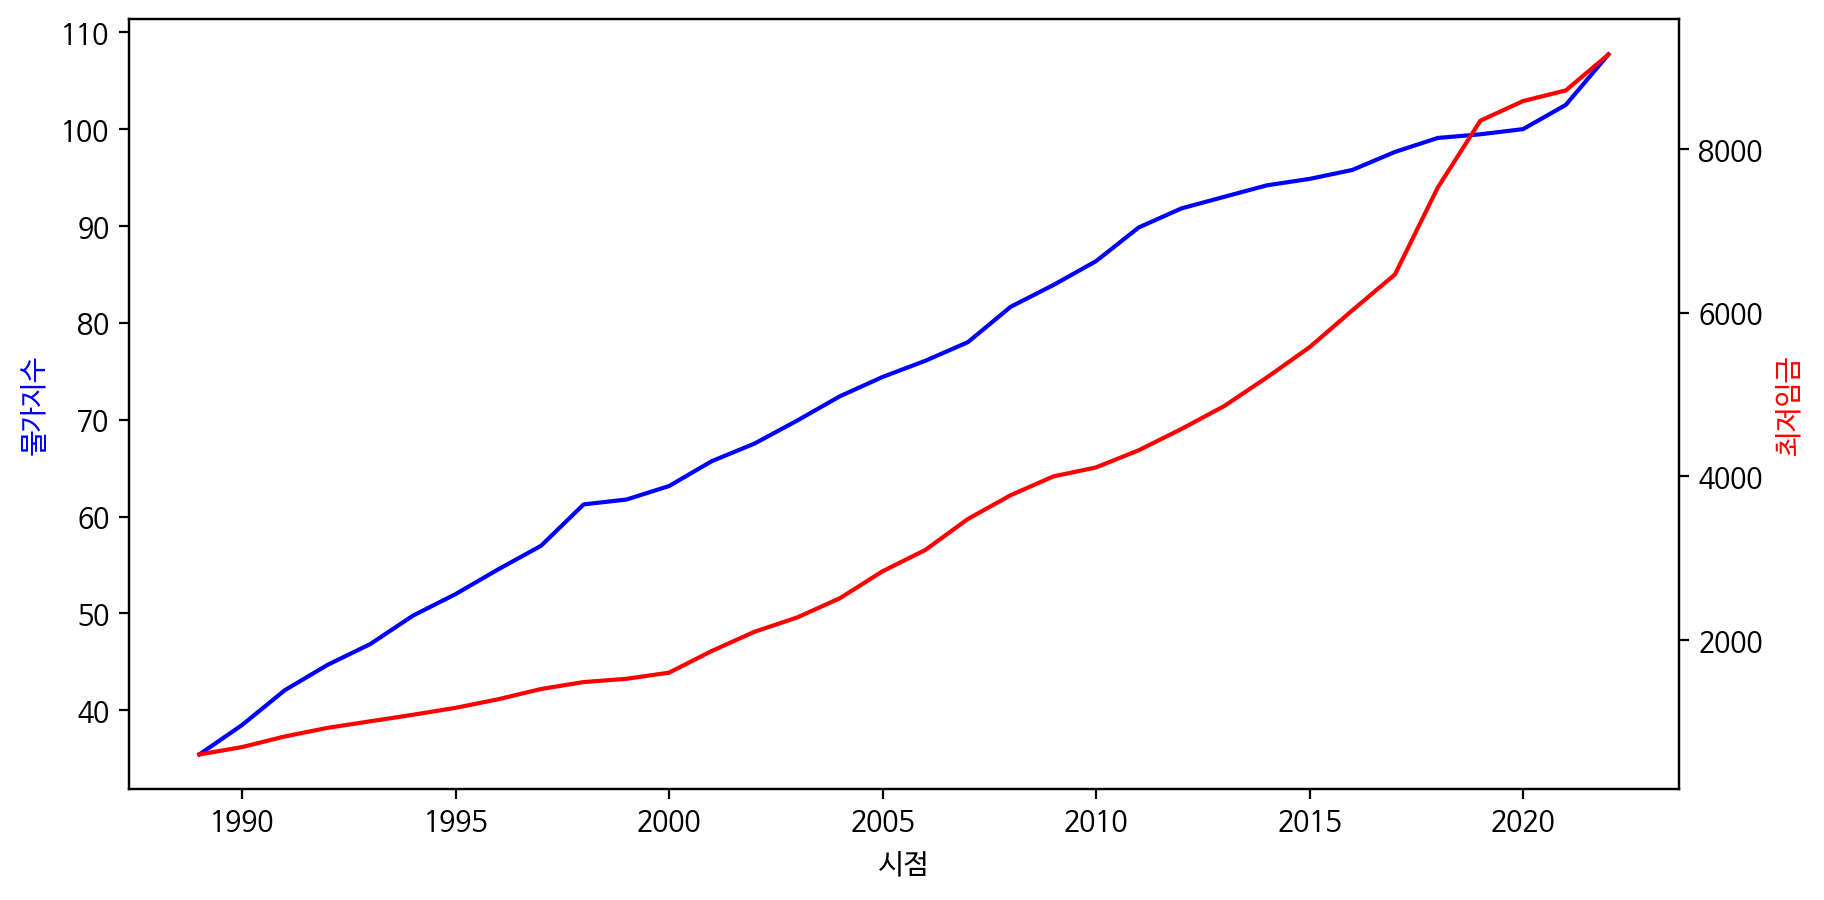

In [6]:
# 그래프 생성
fig, ax1 = plt.subplots(figsize=(10, 5))

# 첫 번째 그래프에는 ‘물가지수’를 표시한다.
ax1.set_xlabel('시점')
ax1.set_ylabel('물가지수', color='b')
ax1.plot(df['시점'], df['물가지수'], color='b')

# 두 번째 Y 축을 추가하고, 두 번째 그래프에는 ‘최저임금’를 표시한다.
ax2 = ax1.twinx()
ax2.set_ylabel('최저임금', color='r')
ax2.plot(df['시점'], df['최저임금'], color='r')

plt.show()

'물가지수'와 '최저임금' 모두 상승하고 있다. 특히 최근들어서는 상승폭이 크다는 것을 알 수 있다.

## 5. 모델학습, 평가 및 예측

① 데이터 전처리
모델 학습에 필요없는 '시점'을 없애준다.

In [7]:
df2 = df[['물가지수','최저임금']]

데이터 세트 중 데이터(X)와 레이블(y)로 분리해 보자.

In [8]:
#df2에서 ‘대여건수’ 속성을 제외한 속성을 훈련용 데이터로 저장한다.
X =df2.drop(['물가지수'],axis=1)

#df_bike2에서 ‘대여건수’ 속성만 추출해서 레이블로 저장한다.
y =df2['물가지수']

#데이터와 레이블의 형태를 출력한다.
print(X.shape, y.shape)

(34, 1) (34,)


In [9]:
X

,최저임금
0,600
1,690
2,820
3,925
4,1005
5,1085
6,1170
7,1275
8,1400
9,1485


In [10]:
y

0      35.441
1      38.480
2      42.071
3      44.685
4      46.831
5      49.765
6      51.995
7      54.555
8      56.977
9      61.258
10     61.756
11     63.151
12     65.719
13     67.534
14     69.908
15     72.418
16     74.413
17     76.081
18     78.010
19     81.656
20     83.906
21     86.373
22     89.850
23     91.815
24     93.010
25     94.196
26     94.861
27     95.783
28     97.645
29     99.086
30     99.466
31    100.000
32    102.500
33    107.710
Name: 물가지수, dtype: float64

데이테와 레이블은 34개로 1개의 속성을 가지고 있다

② 훈련용 및 평가용 데이터로 나누기

사이킷런의 train_test_split( ) 함수를 이용하여 훈련용 데이터, 평가용 데이터, 훈련용 레이블, 평가용 레이블로 나눠 보자

In [11]:
# 데이터를 나누기 위해 train_test_split 함수를 불러온다.
from sklearn.model_selection import train_test_split

# 훈련용 데이터(X_train), 평가용 데이터(X_test),
# 훈련용 레이블(y_train), 평가용 레이블(y_test)에 데이터(X)와 레이블(y)을 나눈다.
# 이때, 데이터를 섞은 후에 나뉘게 되며, 훈련용과 평가용을 80:20의 비율로 나눈다.
X_train,X_test,y_train,y_test = train_test_split(X,y,shuffle=True,test_size=0.3)

# 훈련용 및 평가용 데이터와 레이블의 형태를 출력한다.
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(23, 1) (11, 1) (23,) (11,)


데이터가 적어 30%로 데이터를 나누었으며 훈련용과 평가용이 23개, 11개로 각각 나뉘어졌음을 확인할 수 있다.

전처리된 데이터를 이용해 인공지능 모델을 학습시키고 모델을 평가해 보자.

① 선형 회귀 모델 불러오고 학습하기

사이킷런에서 제공하는 선형 회귀 함수를 불러와 훈련용 데이터(X_train)와 훈련용 레이블(y_train)을 fit( ) 함수로 학습시켜 보자.

In [12]:
# sklearn의 LinearRegression 함수를 불러온다.
from sklearn.linear_model import LinearRegression

# 훈련용 데이터와 레이블을 fit( ) 함수로 학습시키고, 그 결과를 model에 저장한다.
model=LinearRegression().fit(X_train,y_train)

② 모델 평가하기

학습이 잘 되었는지 그리고 모델을 얼마나 신뢰할 수 있는지를 확인하기 위해 모델을 평가해 보자.

In [13]:
# 학습된 모델 평가하기
print('train :',model.score(X_train,y_train)) #훈련용 데이터와 레이블을 통해 결정 계수를 계산하여 출력
print('test: ',model.score(X_test,y_test)) #평가용 데이터와 레이블을 통해 결정 계수를 계산하여 출력

train : 0.8463326395150497
test:  0.8860285421544722


훈련용 데이터와 레이블은 약 0.85, 평가용 데이터와 레이블은 0.84 정도의 결과가 나왔다. 물론, train_test_split( )이 랜덤하게 섞이기 때문에
할 때마다 결과가 달라진다.

③ 평가용 레이블과 평가용 데이터 예측값을 그래프로 그리기

서 평가용 데이터를 예측한 결과와 실제 평가용 레이블을 비교해서 어느 정도 예측했는지 가늠해 보자.

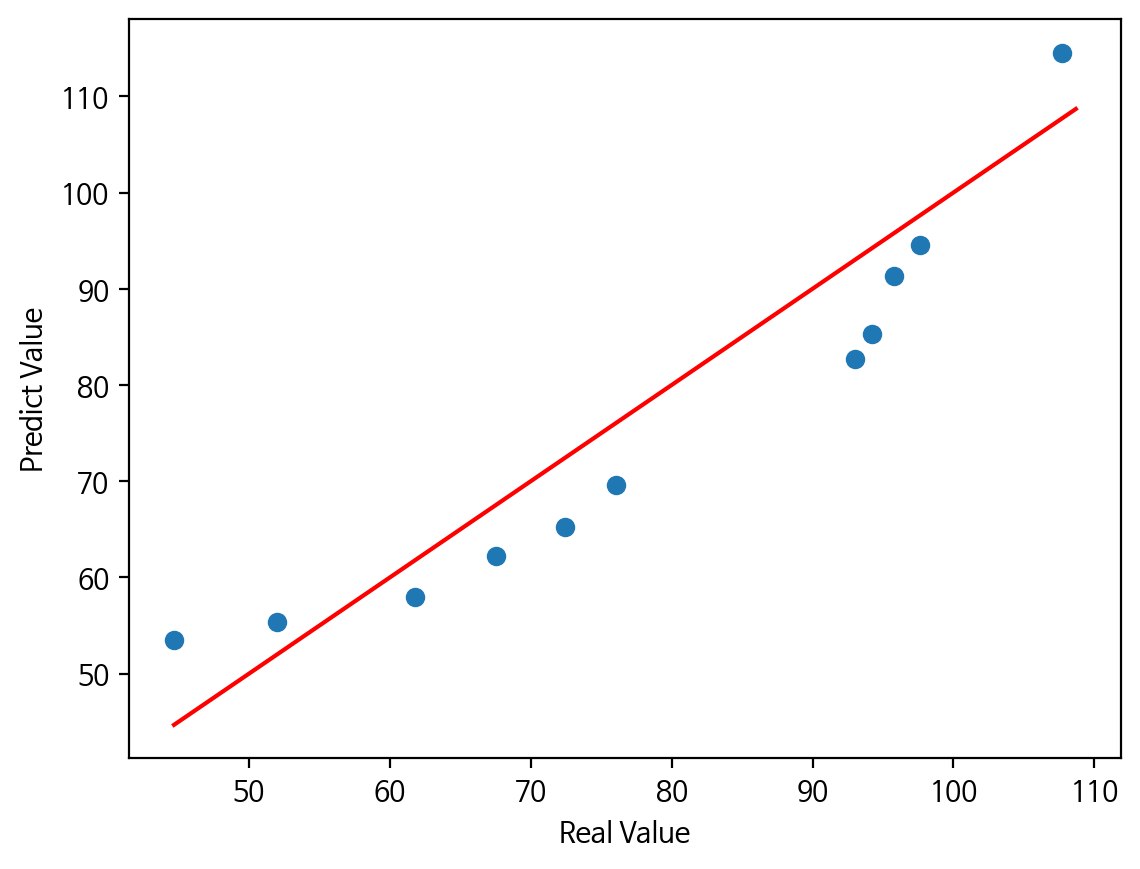

In [14]:
# 평가용 데이터의 최솟값과 최댓값을 x좌표로 설정한다.
x = np.arange(np.min(y_test), np.max(y_test) + 1)

# 평가용 데이터(X_test)의 예측값을 y_pred에 저장한다.
y_pred = model.predict(X_test)

# 평가용 레이블(y_test)은 x축, 평가용 데이터의 예측값(y_pred)은 y축으로 하여 산점도를 그린다.
plt.scatter(y_test,y_pred)

# x, y축 레이블을 설정한다.
plt.xlabel('Real Value')
plt.ylabel('Predict Value')

# y=x 그래프를 기준선으로 선그래프를 그린다.
plt.plot(x, x, 'r')
plt.show( )

예측값이 실젯값을 얼마나 잘 예측했는지 확인하기 위해 실젯값은 x축, 예측값은 y축으로 산점도를 표시했다. 실젯값과 예측값이 y = x 그래프 근처에 있을수록 잘 예측했다고 판단할 수 있다.

④ 입력값 예측하기

입력된 데이터를 구현된 모델에 입력하여 물가 상승률을 출력해 보자.

In [15]:
# 새로운 데이터 입력받기
input_data = float(input("값을 입력하세요: "))
input_data = np.array([[input_data]])

# 학습된 모델에 input_data를 입력하여 예측값을 rent 변수에 저장한다.
minwege = model.predict(input_data)

# 결괏값을 출력한다.
print('(2020년 대비) 예상 물가 상승률: ', float(minwege)-100, '%')

값을 입력하세요: 9000
(2020년 대비) 예상 물가 상승률:  13.331828076332641 %


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 6. 결론 및 제언

오류없이 예측 물가 상승률의 값이 나오기는 하지만 현재의 최저임금 제도가 도입게 비교적 최근이기 때문에 데이터 수가 적어 신뢰도 낮다는 것이 문제이다. 하지만 앞으로 시간이 지나 데이터가 더 많이 생기면 더 정확하고, 더 높은 신뢰도로 값을 예측하여 물가를 예측해주어 기업과 가계의 소비에 도움을 줄 수 있을 것이다.